# Notebook 06: Segmentación de Municipios con K-Means
## Identificación de perfiles territoriales en la utilización de servicios de salud (2009-2021)

#### Setup

In [3]:
import sys
sys.path.append('../src')

import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

# Configuración visual
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 11
sns.set_palette("husl")

# Rutas
GOLD_DIR = Path("../data/gold")
SHAPEFILE_PATH = Path("../data/external/Municipios/Municipios.shp")
RANDOM_STATE = 42

print(f"Gold dir existe: {GOLD_DIR.exists()}")
print(f"Shapefile existe: {SHAPEFILE_PATH.exists()}")

Gold dir existe: True
Shapefile existe: True


#### Carga de Datos

In [4]:
# Cargar indicadores exportados del Notebook 5
df = pd.read_csv(GOLD_DIR / 'municipios_indicadores.csv')

print(f"Municipios cargados: {len(df)}")
print(f"Columnas: {df.columns.tolist()}")
print(f"\nPrimeras filas:")
print(df.head())

# Verificar valores nulos
print(f"\nValores nulos por columna:")
print(df.isnull().sum())

Municipios cargados: 1064
Columnas: ['cod_municipio', 'nombre_municipio', 'cod_departamento', 'nombre_departamento', 'total_atenciones', 'n_registros', 'atenciones_no_def', 'pct_no_def', 'tipo_predominante', 'pct_CONSULTAS', 'pct_HOSPITALIZACIONES', 'pct_PROCEDIMIENTOS DE SALUD', 'pct_URGENCIAS']

Primeras filas:
   cod_municipio        nombre_municipio  cod_departamento  \
0          18001               FLORENCIA                18   
1          18029                 ALBANIA                18   
2          18094  BELEN DE LOS ANDAQUIES                18   
3          18247             EL DONCELLO                18   
4          18256               EL PAUJIL                18   

  nombre_departamento  total_atenciones  n_registros  atenciones_no_def  \
0             Caquetá        11646961.0      98154.0          3202541.0   
1             Caquetá          404777.0      16878.0           170913.0   
2             Caquetá          601587.0      19627.0           239366.0   
3           

#### Feature Engineering

In [5]:
# Crear copia para trabajar
df_features = df.copy()

# ---- 1. LOG DEL VOLUMEN (para manejar la asimetría extrema) ----
df_features['log_total_atenciones'] = np.log10(df_features['total_atenciones'].clip(lower=1))
df_features['log_n_registros'] = np.log10(df_features['n_registros'].clip(lower=1))

# ---- 2. PROPORCIONES DE TIPOS DE ATENCIÓN ----
# Identificar columnas de porcentaje por tipo
tipo_cols = [c for c in df_features.columns if c.startswith('pct_') and c != 'pct_no_def']

# Rellenar NaN con 0 (municipios sin datos)
for col in tipo_cols + ['pct_no_def']:
    if col in df_features.columns:
        df_features[col] = df_features[col].fillna(0)

# ---- 3. RATIOS ENTRE TIPOS ----
# Ratio CONSULTAS / PROCEDIMIENTOS (indica orientación clínica vs quirúrgica)
pct_consultas_col = [c for c in tipo_cols if 'CONSULTAS' in c.upper()]
pct_proced_col = [c for c in tipo_cols if 'PROCEDIMIENTOS' in c.upper()]

if pct_consultas_col and pct_proced_col:
    df_features['ratio_consultas_proced'] = (
        df_features[pct_consultas_col[0]] / 
        (df_features[pct_proced_col[0]] + 0.01)
    )
    df_features['ratio_consultas_proced'] = df_features['ratio_consultas_proced'].clip(upper=10)

# ---- 4. RATIO URGENCIAS/CONSULTAS (indica presión sobre urgencias) ----
pct_urg_col = [c for c in tipo_cols if 'URGENCIAS' in c.upper()]
if pct_urg_col and pct_consultas_col:
    df_features['ratio_urg_consultas'] = (
        df_features[pct_urg_col[0]] / 
        (df_features[pct_consultas_col[0]] + 0.01)
    )

print("Features creadas:")
new_cols = [c for c in df_features.columns if c not in df.columns]
for c in new_cols:
    print(f"  ✅ {c}")

print(f"\nEstadísticas de las nuevas features:")
print(df_features[new_cols].describe().round(3))

Features creadas:
  ✅ log_total_atenciones
  ✅ log_n_registros
  ✅ ratio_consultas_proced
  ✅ ratio_urg_consultas

Estadísticas de las nuevas features:
       log_total_atenciones  log_n_registros  ratio_consultas_proced  \
count              1064.000         1064.000                1064.000   
mean                  5.680            4.205                   0.603   
std                   0.635            0.399                   0.485   
min                   2.037            1.462                   0.143   
25%                   5.268            3.980                   0.466   
50%                   5.642            4.208                   0.556   
75%                   6.007            4.420                   0.655   
max                   8.688            5.435                  10.000   

       ratio_urg_consultas  
count             1064.000  
mean                 0.042  
std                  0.035  
min                  0.000  
25%                  0.018  
50%                  0.03

#### Selección de Features para Clustering

In [6]:
# Seleccionar features para clustering
# IMPORTANTE: usar proporciones y logs, NO valores absolutos
FEATURES = [
    'log_total_atenciones',       # Tamaño del municipio
    'pct_no_def',                  # Calidad de registro
] + tipo_cols  # Proporción de cada tipo de atención

# Filtrar solo las que existen
FEATURES = [f for f in FEATURES if f in df_features.columns]

print("Features seleccionadas para clustering:")
for i, f in enumerate(FEATURES, 1):
    print(f"  {i}. {f}")

# Matriz de features
X = df_features[FEATURES].copy()

print(f"\nForma de la matriz X: {X.shape}")
print(f"Valores nulos: {X.isnull().sum().sum()}")

# Rellenar cualquier NaN restante
X = X.fillna(0)

print(f"\nEstadísticas:")
print(X.describe().round(2))

Features seleccionadas para clustering:
  1. log_total_atenciones
  2. pct_no_def
  3. pct_CONSULTAS
  4. pct_HOSPITALIZACIONES
  5. pct_PROCEDIMIENTOS DE SALUD
  6. pct_URGENCIAS

Forma de la matriz X: (1064, 6)
Valores nulos: 0

Estadísticas:
       log_total_atenciones  pct_no_def  pct_CONSULTAS  pct_HOSPITALIZACIONES  \
count               1064.00     1064.00        1064.00                1064.00   
mean                   5.68       26.12          35.26                   0.71   
std                    0.64       15.24           6.99                   0.31   
min                    2.04        0.00          12.38                   0.20   
25%                    5.27       13.93          31.15                   0.54   
50%                    5.64       23.80          34.82                   0.67   
75%                    6.01       36.68          38.39                   0.84   
max                    8.69       70.86          96.45                   4.03   

       pct_PROCEDIMIENTOS

#### Escalado de Features

In [7]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=FEATURES)

print("Estadísticas después del escalado:")
print(X_scaled_df.describe().round(3))

# Verificar que la media sea ~0 y std ~1
print(f"\nMedia (debe ser ~0): {X_scaled_df.mean().mean():.6f}")
print(f"Std (debe ser ~1): {X_scaled_df.std().mean():.4f}")

Estadísticas después del escalado:
       log_total_atenciones  pct_no_def  pct_CONSULTAS  pct_HOSPITALIZACIONES  \
count              1064.000    1064.000       1064.000               1064.000   
mean                  0.000      -0.000         -0.000                  0.000   
std                   1.000       1.000          1.000                  1.000   
min                  -5.738      -1.715         -3.277                 -1.644   
25%                  -0.649      -0.800         -0.589                 -0.558   
50%                  -0.060      -0.152         -0.064                 -0.142   
75%                   0.515       0.693          0.448                  0.401   
max                   4.740       2.937          8.763                 10.590   

       pct_PROCEDIMIENTOS DE SALUD  pct_URGENCIAS  
count                     1064.000       1064.000  
mean                         0.000          0.000  
std                          1.000          1.000  
min                        

#### Determinación del Número Óptimo de Clusters

Evaluando k = 2 a 10...
  k=2: Inercia=5082, Silhouette=0.1981
  k=3: Inercia=4451, Silhouette=0.1763
  k=4: Inercia=3864, Silhouette=0.1977
  k=5: Inercia=3390, Silhouette=0.2043
  k=6: Inercia=3043, Silhouette=0.2179
  k=7: Inercia=2804, Silhouette=0.2154
  k=8: Inercia=2597, Silhouette=0.2094
  k=9: Inercia=2466, Silhouette=0.1866
  k=10: Inercia=2307, Silhouette=0.1871


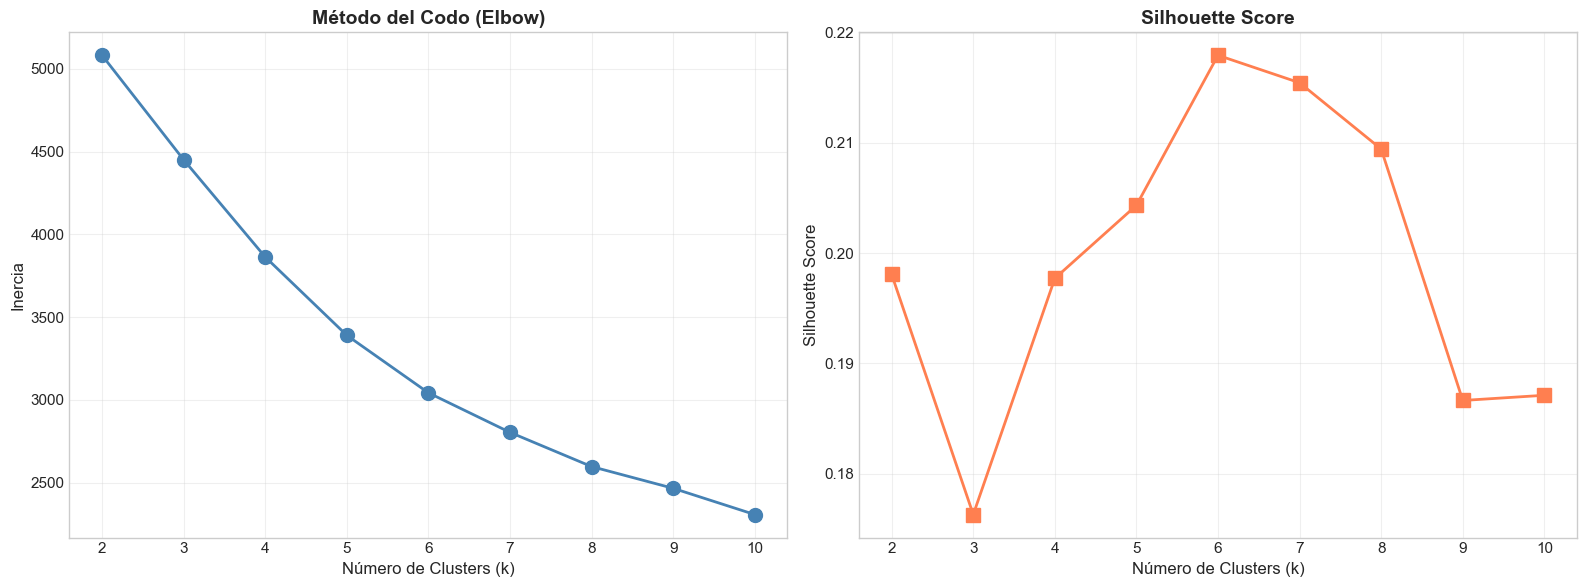


✅ k óptimo según Silhouette: 6 (score=0.2179)


In [8]:
# Rango de k a evaluar
k_range = range(2, 11)
inertias = []
silhouettes = []

print("Evaluando k = 2 a 10...")
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10, max_iter=300)
    labels = kmeans.fit_predict(X_scaled)
    inertias.append(kmeans.inertia_)
    sil = silhouette_score(X_scaled, labels, sample_size=min(1000, len(X_scaled)))
    silhouettes.append(sil)
    print(f"  k={k}: Inercia={kmeans.inertia_:.0f}, Silhouette={sil:.4f}")

# Gráficos
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Elbow
axes[0].plot(list(k_range), inertias, marker='o', linewidth=2, markersize=10, color='steelblue')
axes[0].set_title('Método del Codo (Elbow)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Número de Clusters (k)', fontsize=12)
axes[0].set_ylabel('Inercia', fontsize=12)
axes[0].grid(True, alpha=0.3)

# Silhouette
axes[1].plot(list(k_range), silhouettes, marker='s', linewidth=2, markersize=10, color='coral')
axes[1].set_title('Silhouette Score', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Número de Clusters (k)', fontsize=12)
axes[1].set_ylabel('Silhouette Score', fontsize=12)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../reports/figures/06_elbow_silhouette.png', dpi=150, bbox_inches='tight')
plt.show()

# Sugerir k óptimo
optimal_k_sil = list(k_range)[np.argmax(silhouettes)]
print(f"\n✅ k óptimo según Silhouette: {optimal_k_sil} (score={max(silhouettes):.4f})")

#### Aplicación de K-Means con k Óptimo

In [9]:
# ⚠️ Ajusta el valor de K según el gráfico anterior
# Sugerencia: entre 4 y 5 suele dar la mejor interpretabilidad de negocio
K_OPTIMO = optimal_k_sil  # o cambia a 4 manualmente si prefieres

print(f"Aplicando K-Means con k = {K_OPTIMO}...")

kmeans_final = KMeans(
    n_clusters=K_OPTIMO, 
    random_state=RANDOM_STATE, 
    n_init=20,
    max_iter=500
)

# Asignar clusters
df_features['cluster'] = kmeans_final.fit_predict(X_scaled)

print(f"\nDistribución de municipios por cluster:")
print(df_features['cluster'].value_counts().sort_index().to_string())

# Tamaño de cada cluster (%)
print(f"\nPorcentaje de municipios por cluster:")
print((df_features['cluster'].value_counts(normalize=True).sort_index() * 100).round(2).to_string())

Aplicando K-Means con k = 6...

Distribución de municipios por cluster:
cluster
0      7
1    266
2    183
3    172
4    311
5    125

Porcentaje de municipios por cluster:
cluster
0     0.66
1    25.00
2    17.20
3    16.17
4    29.23
5    11.75


#### Interpretación de los Clusters

In [10]:
# Estadísticas por cluster
perfil_clusters = df_features.groupby('cluster').agg({
    'total_atenciones': ['mean', 'median', 'sum'],
    'n_registros': 'mean',
    'pct_no_def': 'mean',
    'log_total_atenciones': 'mean',
    'ratio_consultas_proced': 'mean',
}).round(2)

print("=" * 80)
print("PERFIL DE CLUSTERS (promedios)")
print("=" * 80)
print(perfil_clusters.to_string())

# Perfil por tipo de atención
print("\n" + "=" * 80)
print("DISTRIBUCIÓN POR TIPO DE ATENCIÓN")
print("=" * 80)
perfil_tipos = df_features.groupby('cluster')[tipo_cols].mean().round(2)
print(perfil_tipos.to_string())

PERFIL DE CLUSTERS (promedios)
        total_atenciones                          n_registros pct_no_def log_total_atenciones ratio_consultas_proced
                    mean     median           sum        mean       mean                 mean                   mean
cluster                                                                                                             
0                8386.00     1564.0  5.870200e+04      445.57       0.00                 3.24                   5.25
1             1032165.50   571640.5  2.745560e+08    19820.52      45.37                 5.76                   0.45
2              257898.03   176903.0  4.719534e+07    11895.21      23.90                 5.24                   0.73
3            10752200.21  2525663.5  1.849378e+09    58507.05      20.55                 6.49                   0.72
4              403872.63   297419.0  1.256044e+08    13981.10      15.00                 5.44                   0.50
5              997463.16   553433

#### Interpretación de los Clusters

In [11]:
# Estadísticas por cluster
perfil_clusters = df_features.groupby('cluster').agg({
    'total_atenciones': ['mean', 'median', 'sum'],
    'n_registros': 'mean',
    'pct_no_def': 'mean',
    'log_total_atenciones': 'mean',
    'ratio_consultas_proced': 'mean',
}).round(2)

print("=" * 80)
print("PERFIL DE CLUSTERS (promedios)")
print("=" * 80)
print(perfil_clusters.to_string())

# Perfil por tipo de atención
print("\n" + "=" * 80)
print("DISTRIBUCIÓN POR TIPO DE ATENCIÓN")
print("=" * 80)
perfil_tipos = df_features.groupby('cluster')[tipo_cols].mean().round(2)
print(perfil_tipos.to_string())

PERFIL DE CLUSTERS (promedios)
        total_atenciones                          n_registros pct_no_def log_total_atenciones ratio_consultas_proced
                    mean     median           sum        mean       mean                 mean                   mean
cluster                                                                                                             
0                8386.00     1564.0  5.870200e+04      445.57       0.00                 3.24                   5.25
1             1032165.50   571640.5  2.745560e+08    19820.52      45.37                 5.76                   0.45
2              257898.03   176903.0  4.719534e+07    11895.21      23.90                 5.24                   0.73
3            10752200.21  2525663.5  1.849378e+09    58507.05      20.55                 6.49                   0.72
4              403872.63   297419.0  1.256044e+08    13981.10      15.00                 5.44                   0.50
5              997463.16   553433

#### Nombres de clusters

In [12]:
# Definir nombres significativos según interpretación
cluster_names_final = {
    0: 'Rurales pequeños - perfil clínico',
    1: 'Alta carga NO DEFINIDO',
    2: 'Perfil quirúrgico medio',
    3: 'Grandes centros urbanos',
    4: 'Perfil quirúrgico con buen registro',
    5: 'Alta demanda de urgencias'
}

# Aplicar
df_features['cluster_nombre'] = df_features['cluster'].map(cluster_names_final)

# Verificar
print("Distribución de clusters con nombres:")
resumen = df_features.groupby(['cluster', 'cluster_nombre']).agg({
    'cod_municipio': 'count',
    'total_atenciones': 'sum',
    'pct_no_def': 'mean'
}).round(2)
resumen.columns = ['n_municipios', 'atenciones_totales', 'pct_no_def_prom']
resumen = resumen.reset_index()
print(resumen.to_string(index=False))

# Guardar tabla
resumen.to_csv(GOLD_DIR / 'cluster_nombres.csv', index=False)

Distribución de clusters con nombres:
 cluster                      cluster_nombre  n_municipios  atenciones_totales  pct_no_def_prom
       0   Rurales pequeños - perfil clínico             7             58702.0             0.00
       1              Alta carga NO DEFINIDO           266         274556023.0            45.37
       2             Perfil quirúrgico medio           183          47195339.0            23.90
       3             Grandes centros urbanos           172        1849378436.0            20.55
       4 Perfil quirúrgico con buen registro           311         125604387.0            15.00
       5           Alta demanda de urgencias           125         124682895.0            25.22


#### Exportación

In [13]:
municipios_cluster = df_features[[
    'cod_municipio', 'nombre_municipio', 'nombre_departamento',
    'cluster', 'cluster_nombre',
    'total_atenciones', 'n_registros', 'pct_no_def',
    'log_total_atenciones', 'ratio_consultas_proced'
] + tipo_cols].copy()

municipios_cluster.to_csv(GOLD_DIR / 'municipios_cluster.csv', index=False)
print(f"✅ data/gold/municipios_cluster.csv ({len(municipios_cluster)} municipios, {(GOLD_DIR / 'municipios_cluster.csv').stat().st_size / 1024:.0f} KB)")

✅ data/gold/municipios_cluster.csv (1064 municipios, 143 KB)


In [14]:
perfil_export = df_features.groupby(['cluster', 'cluster_nombre']).agg({
    'cod_municipio': 'count',
    'total_atenciones': 'sum',
    'pct_no_def': 'mean',
    'ratio_consultas_proced': 'mean'
}).round(2)

perfil_export.columns = ['n_municipios', 'total_atenciones', 'pct_no_def_prom', 'ratio_consultas_proced']
perfil_export = perfil_export.reset_index()

perfil_export.to_csv(GOLD_DIR / 'perfil_clusters.csv', index=False)
print(f"✅ data/gold/perfil_clusters.csv ({len(perfil_export)} clusters)")
print(perfil_export.to_string(index=False))

✅ data/gold/perfil_clusters.csv (6 clusters)
 cluster                      cluster_nombre  n_municipios  total_atenciones  pct_no_def_prom  ratio_consultas_proced
       0   Rurales pequeños - perfil clínico             7           58702.0             0.00                    5.25
       1              Alta carga NO DEFINIDO           266       274556023.0            45.37                    0.45
       2             Perfil quirúrgico medio           183        47195339.0            23.90                    0.73
       3             Grandes centros urbanos           172      1849378436.0            20.55                    0.72
       4 Perfil quirúrgico con buen registro           311       125604387.0            15.00                    0.50
       5           Alta demanda de urgencias           125       124682895.0            25.22                    0.57


In [17]:
import geopandas as gpd
from pathlib import Path

# ---- 1. CARGAR EL SHAPEFILE ----
SHAPEFILE_PATH = Path("../data/external/Municipios/Municipios.shp")
gdf_municipios = gpd.read_file(SHAPEFILE_PATH)

# ---- 2. RECONSTRUIR CÓDIGOS DIVIPOLA ----
dpto_str = gdf_municipios['DPTO_CCDGO'].astype(str).str.replace('.0', '', regex=False).str.zfill(2)
mpio_str = gdf_municipios['MPIO_CCDGO'].astype(str).str.replace('.0', '', regex=False).str.zfill(3).str[-3:]
gdf_municipios['cod_municipio'] = dpto_str + mpio_str

print(f"✅ Shapefile cargado: {len(gdf_municipios)} municipios")

# ---- 3. 🔧 CLAVE: CONVERTIR cod_municipio DE df_features A STRING DE 5 DÍGITOS ----
df_features['cod_municipio'] = df_features['cod_municipio'].astype(str).str.replace('.0', '', regex=False).str.zfill(5)

# Verificar que los tipos coincidan
print(f"\nTipo en gdf_municipios: {gdf_municipios['cod_municipio'].dtype}")
print(f"Tipo en df_features:    {df_features['cod_municipio'].dtype}")
print(f"\nEjemplo shapefile: {gdf_municipios['cod_municipio'].head(3).tolist()}")
print(f"Ejemplo df_features: {df_features['cod_municipio'].head(3).tolist()}")

# ---- 4. MERGE CON CLUSTERS ----
gdf_clusters_final = gdf_municipios.merge(
    df_features[['cod_municipio', 'cluster', 'cluster_nombre']],
    on='cod_municipio',
    how='left'
)

print(f"\n✅ Merge realizado: {len(gdf_clusters_final)} filas")
print(f"   Municipios con cluster: {gdf_clusters_final['cluster'].notna().sum()}")

# ---- 5. PREPARAR GEOJSON ----
gdf_geo = gdf_clusters_final[['cod_municipio', 'cluster', 'cluster_nombre', 'geometry']].copy()
gdf_geo = gdf_geo[gdf_geo['cluster'].notna()].copy()

print(f"Municipios con cluster asignado: {len(gdf_geo)}")

# ---- 6. REPROJECTAR A WGS84 ----
if gdf_geo.crs is not None and gdf_geo.crs.to_epsg() != 4326:
    print(f"Reprojectando de {gdf_geo.crs} a EPSG:4326...")
    gdf_geo = gdf_geo.to_crs("EPSG:4326")

# ---- 7. SIMPLIFICAR GEOMETRÍA ----
gdf_geo['geometry'] = gdf_geo['geometry'].simplify(0.01)

# ---- 8. EXPORTAR ----
output_path = GOLD_DIR / 'municipios_cluster.geojson'
gdf_geo.to_file(output_path, driver='GeoJSON')

print(f"\n✅ GeoJSON exportado: {output_path}")
print(f"   Municipios: {len(gdf_geo)}")
print(f"   Tamaño: {output_path.stat().st_size / 1024 / 1024:.2f} MB")

# ---- 9. VERIFICAR ----
print(f"\nDistribución de clusters en el GeoJSON:")
print(gdf_geo['cluster'].value_counts().sort_index().to_string())

✅ Shapefile cargado: 1118 municipios

Tipo en gdf_municipios: object
Tipo en df_features:    object

Ejemplo shapefile: ['18001', '18029', '18094']
Ejemplo df_features: ['18001', '18029', '18094']

✅ Merge realizado: 1118 filas
   Municipios con cluster: 1064
Municipios con cluster asignado: 1064

✅ GeoJSON exportado: ..\data\gold\municipios_cluster.geojson
   Municipios: 1064
   Tamaño: 1.19 MB

Distribución de clusters en el GeoJSON:
cluster
0.0      7
1.0    266
2.0    183
3.0    172
4.0    311
5.0    125


In [18]:
from pathlib import Path
import geopandas as gpd

# Leer el GeoJSON, convertir cluster a int, y volver a guardar
gdf_fix = gpd.read_file(GOLD_DIR / 'municipios_cluster.geojson')
gdf_fix['cluster'] = gdf_fix['cluster'].astype(int)

# Guardar
gdf_fix.to_file(GOLD_DIR / 'municipios_cluster.geojson', driver='GeoJSON')
print(f"✅ Cluster convertido a int: {gdf_fix['cluster'].dtype}")
print(gdf_fix['cluster'].value_counts().sort_index().to_string())

✅ Cluster convertido a int: int32
cluster
0      7
1    266
2    183
3    172
4    311
5    125


In [19]:
# Corregir el CSV también
mun_fix = pd.read_csv(GOLD_DIR / 'municipios_cluster.csv')
mun_fix['cluster'] = mun_fix['cluster'].astype(int)
mun_fix.to_csv(GOLD_DIR / 'municipios_cluster.csv', index=False)
print(f"✅ CSV corregido: cluster = {mun_fix['cluster'].dtype}")

✅ CSV corregido: cluster = int32


#### Verificación final

In [20]:
from pathlib import Path

print("=" * 60)
print("VERIFICACIÓN FINAL - NOTEBOOK 6")
print("=" * 60)

print("\n📊 Figuras (reports/figures/):")
for f in sorted(Path('../reports/figures').glob('06_*.png')):
    print(f"  ✅ {f.name} ({f.stat().st_size / 1024:.0f} KB)")

print("\n💾 Datos para Power BI (data/gold/):")
archivos_esperados = [
    'municipios_cluster.csv',
    'municipios_cluster.geojson',
    'perfil_clusters.csv'
]
for fname in archivos_esperados:
    f = GOLD_DIR / fname
    if f.exists():
        size_kb = f.stat().st_size / 1024
        print(f"  ✅ {fname} ({size_kb:.0f} KB)")
    else:
        print(f"  ❌ {fname} NO EXISTE")

print("\n" + "=" * 60)
print("🎉 Notebook 6 completado")
print("=" * 60)

VERIFICACIÓN FINAL - NOTEBOOK 6

📊 Figuras (reports/figures/):
  ✅ 06_elbow_silhouette.png (106 KB)

💾 Datos para Power BI (data/gold/):
  ✅ municipios_cluster.csv (143 KB)
  ✅ municipios_cluster.geojson (1219 KB)
  ✅ perfil_clusters.csv (0 KB)

🎉 Notebook 6 completado
